In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl

from matplotlib.collections import PathCollection
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

### __Random Forest Classifier__
This script implements a Random Forest Classifier using the scikit-learn library.

In [2]:
# Set the random seed for reproducibility
rnd_state = 24

#### __General plotting functions__

In [3]:
def create_confusion_matrix(y_train, y_test, y_train_proba, y_test_proba, classification_thr, title=None, show=False):

    # Convert the predicted probabilities into class predictions based on set classification threshold
    y_train_pred = y_train_proba >= classification_thr
    y_test_pred = y_test_proba >= classification_thr

    # Create figure with axes such that confusion matrices are side by side
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    
    # Add figure title if specified
    if title is not None:
        fig.suptitle(
            f'{title}\n(Classification threshold = {classification_thr})',
            fontsize=16
        )

    # Create confusion matrices for the train and test datasets
    cm_train = ConfusionMatrixDisplay.from_predictions(
        y_pred=y_train_pred,
        y_true=y_train,
        labels=[1, 0],
        display_labels=['Positive test (1)', 'Negative test (0)'],
        normalize='true',
        ax=axes[0],
    )
    cm_train.ax_.set_title(f'Train dataset ({len(y_train)} samples)')

    cm_test = ConfusionMatrixDisplay.from_predictions(
        y_pred=y_test_pred,
        y_true=y_test,
        labels=[1, 0],
        display_labels=['Positive test (1)', 'Negative test (0)'],
        normalize='true',
        ax=axes[1],
    )
    cm_test.ax_.set_title(f'Test dataset ({len(y_test)} samples)')

    # Tighten the layout of the figure
    plt.tight_layout()

    # Render figure inline if specified
    if show:
        plt.show()

    return fig, axes

In [4]:
# Define a function that generates an ROC curve for a classifiers predictions on the train and test datasets
def create_roc_curves(y_train, y_test, y_train_proba, y_test_proba, classification_thr, title=None, show=False):
                      
    # Calculate the fpr, tpr, and thresholds for both the train and test datasets
    train_fpr, train_tpr, train_thr = roc_curve(y_train, y_train_proba)
    test_fpr, test_tpr, test_thr = roc_curve(y_test, y_test_proba)

    # Calculate the AUC for both the train and test ROC curves
    train_auc = auc(train_fpr, train_tpr)
    test_auc = auc(test_fpr, test_tpr)

    # Create a figure
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 5))
    
    # Format the figure
    ax.set_xlabel('False positive rate\n(FPR)')
    ax.set_ylabel('True positive rate\n(TPR)')
    ax.minorticks_on()
    ax.grid(visible=True, which='major', color='k', linestyle='--', alpha=0.3)
    ax.grid(visible=True, which='minor', color='k', linestyle=':', alpha=0.15)
    ax.tick_params(which='major', direction='in', length=6)
    ax.tick_params(which='minor', direction='in', length=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # Add figure title if specified
    if title is not None:
        fig.suptitle(title, fontsize=16)
    
    # Plot the ROC curves for the classifier
    ax.plot(
        train_fpr,
        train_tpr,
        label=f'Train dataset (AUC = {train_auc:.3f})',
        color='royalblue',
        zorder=1,
    )

    ax.plot(
        test_fpr,
        test_tpr,
        label=f'Test dataset (AUC = {test_auc:.3f})',
        color='orange',
        zorder=1,
    )

    # Add the ROC point for the classification threshold specified
    train_thr_idx = np.argmin(np.abs(train_thr - classification_thr))
    test_thr_idx = np.argmin(np.abs(test_thr - classification_thr))
    ax.scatter(
        train_fpr[train_thr_idx],
        train_tpr[train_thr_idx],
        marker='x',
        color='royalblue',
        label=f'Custom threshold ({classification_thr:.2f})',
        zorder=2,
    )
    ax.scatter(
        test_fpr[test_thr_idx],
        test_tpr[test_thr_idx],
        marker='x',
        color='orange',
        zorder=2,
    )
    
    # Find and add the ROC point for the classification threshold that maximises the Youden's J statistic
    # Should only be done on train dataset and then applied to test dataset; avoids data leakage
    #youden_j_value = train_tpr - train_fpr
    #optimal_thr_idx = np.argmax(youden_j_value)  # Find the index of the threshold that maximises Youden's J statistic
    #optimal_classification_thr = train_thr[optimal_thr_idx]   # Find threshold that maximises Youden's J statistic
    #ax.scatter(
    #    train_fpr[optimal_thr_idx],
    #    train_tpr[optimal_thr_idx],
    #    marker='D',
    #    color='royalblue',
    #    label=f'Youden\'s J threshold ({optimal_classification_thr:.2f})',
    #    zorder=2,
    #)
    
    # Apply the optimal threshold derived from the train dataset to the test ROC curve
    #test_optimal_thr_idx = np.argmin(np.abs(test_thr - optimal_classification_thr))
    #ax.scatter(
    #    test_fpr[test_optimal_thr_idx],
    #    test_tpr[test_optimal_thr_idx],
    #    marker='D',
    #    color='orange',
    #    zorder=2,
    #)
    
    # Plot expected behaviour of a random classifer; one that randomly guesses the class of each sample
    ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')

    # Add legend, ensuring the threshold markers are a netural colour
    # Use how scatter markers are represented as a PathCollection in the legend
    legend = ax.legend(loc='lower right')
    for handle in legend.legend_handles:
        if isinstance(handle, PathCollection):
            handle.set_facecolor('grey')
            handle.set_edgecolor('grey')
    
    # Gather the ROC metrics into a dictionary object
    roc_metrics = {
        'train_fpr': train_fpr,
        'train_tpr': train_tpr,
        'train_thr': train_thr,
        'train_auc': train_auc,
        'test_fpr': test_fpr,
        'test_tpr': test_tpr,
        'test_thr': test_thr,
        'test_auc': test_auc,
    }

    # Render figure inline if specified
    if show:
        plt.show()
        
    # Tighten the layout of the figure
    plt.tight_layout()
    
    return fig, ax, roc_metrics
    

#### __Preprocessing__

In [5]:

# Read-in the dataset as a pandas dataframe
df = pd.read_csv('data/corona_tested_individuals_ver_006.csv', low_memory=False)

# Remove rows with "other" and convert the time to datetime object
df = df[df['corona_result'] != 'other']
df['test_date'] = pd.to_datetime(df['test_date'], dayfirst=True)

# Keep only the features used in Zoabi et al. (2021)
df = df.drop(['test_date'], axis=1)

# Convert categorical data to binary data whilst keeping NaNs as is
df['corona_result'] = df['corona_result'].map({'negative': 0, 'positive': 1})
df['gender'] = df['gender'].map({'female': 0, 'male': 1})
df['age_60_and_above'] = df['age_60_and_above'].map({'No': 0, 'Yes': 1})

# Create target and features datasets
X = df.drop('corona_result', axis=1).copy()
y = df['corona_result'].copy()

# Inspect the balance of the data
print(f'+ve/-ve counts: {y.value_counts(normalize=True)}')

# Dataset is highly imbalanced
# TODO: Consider oversampling techniques to balance the dataset

+ve/-ve counts: corona_result
0    0.946431
1    0.053569
Name: proportion, dtype: float64


In [6]:
# Define the categorical and numerical features
cat_features = ['test_indication']
num_features = ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'age_60_and_above', 'gender']

# Instantiate a column transformer that:
# a) One-hot encodes the categorical features
# b) Do we want to address numerical features NaNs? (e.g. drop or impute?)
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot_encode', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='passthrough',
    n_jobs=-1
)

In [7]:
# Sanity check one-hot encoding
#test_arr = preprocessor.fit_transform(X_train)
#feature_names = preprocessor.get_feature_names_out()
#test_df = pd.DataFrame(test_arr, columns=feature_names, index=X_train.index)
#test_df

#### __Model training__

In [8]:
# Create train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=rnd_state,
    stratify=y
)

In [13]:
# Instantiate a stratified k-fold cross-validation instance to use for hyper-parameter tuning
# Ensures the pass/fail ratio is maintained in each fold
stratified_kfold_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=rnd_state,
)

# Specify the scoring metrics to use for model validation
scoring_metrics = [
    'roc_auc',
    'precision',
    'recall',
    'f1',
    'average_precision',
]

In [10]:
# Instantiate a random forest classifier
# A subset of the hyper-parameters specfied here will be tuned using GridSearchCV
rf_classifier = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    criterion='gini',  # Split quality criterion
    max_depth=5,  # Maximum depth of the tree
    min_samples_split=2,  # Minimum number of samples required to split an internal node
    min_samples_leaf=1,  # Minimum number of samples required to be at a leaf node
    class_weight='balanced',  # Adjust weights inversely proportional to class frequencies
    random_state=rnd_state,
)

# Construct a pipeline that combines the scaler and the random forest classifier
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('rf_classifier', rf_classifier),
    ]
)
rf_pipeline

,steps,"[('preprocessor', ...), ('rf_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
# Specify the grid of hyper-parameter values to explore for the random forest classifier
rf_param_grid = {
    'rf_classifier__n_estimators': [50],
    'rf_classifier__criterion': ['gini', 'log_loss'],
    'rf_classifier__max_depth': [15],
    'rf_classifier__max_features': ['sqrt', 0.6],
    'rf_classifier__min_samples_split': [8, 12],
    'rf_classifier__min_samples_leaf': [6],
    'rf_classifier__class_weight': ['balanced', 'balanced_subsample'],
}

# Train the random forest model on the train dataset, tuning the hyper-parameters using cross-validation
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=scoring_metrics,
    cv=stratified_kfold_cv,
    return_train_score=True,
    refit='roc_auc',  # Optimise for ROC AUC
    verbose=2,
    n_jobs=-1,
)
rf_grid_search.fit(X_train, y_train)

# Output the optimal hyper-parameter values found by the grid search
print(f'Random forest optimal hyper-parameters: {rf_grid_search.best_params_}')

# Output pipeline view of the best estimator found by the grid search
rf_grid_search.best_estimator_

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END rf_classifier__class_weight=balanced, rf_classifier__criterion=gini, rf_classifier__max_depth=15, rf_classifier__max_features=sqrt, rf_classifier__min_samples_leaf=6, rf_classifier__min_samples_split=8, rf_classifier__n_estimators=50; total time=  13.7s
[CV] END rf_classifier__class_weight=balanced, rf_classifier__criterion=gini, rf_classifier__max_depth=15, rf_classifier__max_features=sqrt, rf_classifier__min_samples_leaf=6, rf_classifier__min_samples_split=8, rf_classifier__n_estimators=50; total time=  15.0s
[CV] END rf_classifier__class_weight=balanced, rf_classifier__criterion=gini, rf_classifier__max_depth=15, rf_classifier__max_features=sqrt, rf_classifier__min_samples_leaf=6, rf_classifier__min_samples_split=8, rf_classifier__n_estimators=50; total time=  16.8s
[CV] END rf_classifier__class_weight=balanced, rf_classifier__criterion=gini, rf_classifier__max_depth=15, rf_classifier__max_features=sqrt, rf_classi

,steps,"[('preprocessor', ...), ('rf_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Save model with the best parameters
with open('random_forest_classifier.pkl', 'wb') as f:
    pkl.dump(rf_grid_search.best_estimator_, f)

,steps,"[('preprocessor', ...), ('rf_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encode', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### __Model evaluation__

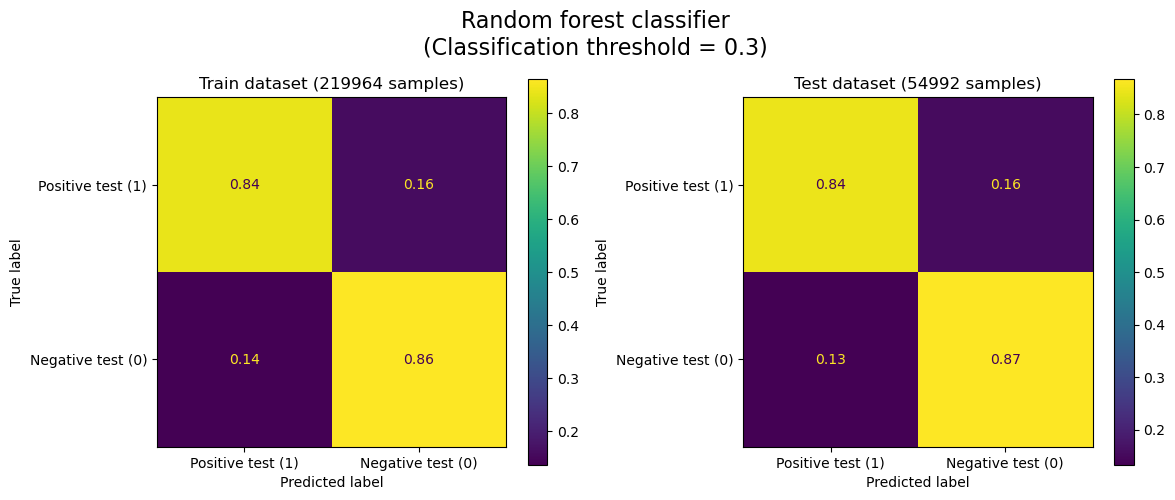

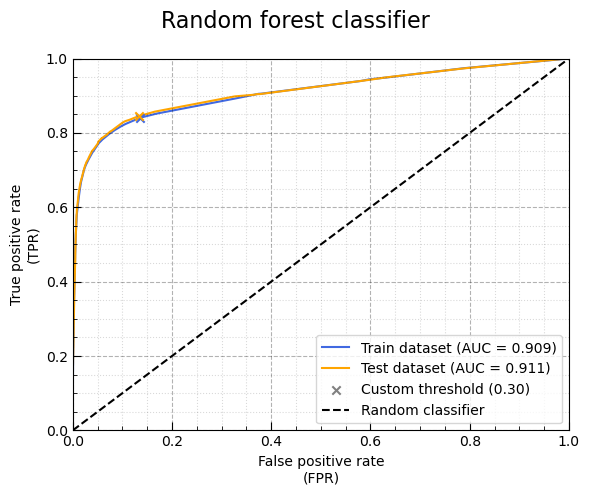

In [16]:
# Generate prediction probabilities for the train and test datasets
# Keep only the positive class probabilities (as binary can just do 1 - p for the negative class)
y_train_rf_proba = rf_grid_search.best_estimator_.predict_proba(X_train)[:, 1]
y_test_rf_proba = rf_grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Specify the classification threshold to use for the random forest classifer predictions
rf_classification_thr = 0.3

# Generate confusion matrices for the random forest classifier predictions
cm_fig, cm_axes = create_confusion_matrix(
    y_train=y_train,
    y_test=y_test,
    y_train_proba=y_train_rf_proba,
    y_test_proba=y_test_rf_proba,
    classification_thr=rf_classification_thr,
    title='Random forest classifier'
)

# Generate the ROC curves for the random forest classifer predictions
roc_fig, roc_ax, roc_metrics = create_roc_curves(
    y_train=y_train,
    y_test=y_test,
    y_train_proba=y_train_rf_proba,
    y_test_proba=y_test_rf_proba,
    classification_thr=rf_classification_thr,
    title='Random forest classifier'
)

In [ ]:
# Extract feature importances from the best random forest estimator
rf_best = rf_grid_search.best_estimator_

# Get the feature names post one-hot encoding
feature_names = rf_best.named_steps['preprocessor'].get_feature_names_out()

# Get the features importances
feature_importances = rf_best.named_steps['rf_classifier'].feature_importances_

# Build a labelled Series
rf_feature_importances = pd.Series(feature_importances, index=feature_names).sort_values(ascending=True)

# Plot feature importances
fig, ax = plt.subplots(figsize=(8, len(rf_feature_importances) * 0.3))
rf_feature_importances.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature importance (mean decrease in impurity)')
ax.set_title('Random forest classifier\nFeature importances')
plt.tight_layout()
plt.show()